Here, we will use our cleaned_news.csv from data preparation part and use it as new dataframe


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
!pip install newspaper3k tqdm

In [8]:
df = pd.read_csv("cleaned_news.csv")

Lets see the distrubiton of news in a plot.

label
0    16448
1     5247
Name: count, dtype: int64


/tmp/ipython-input-3691549218.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


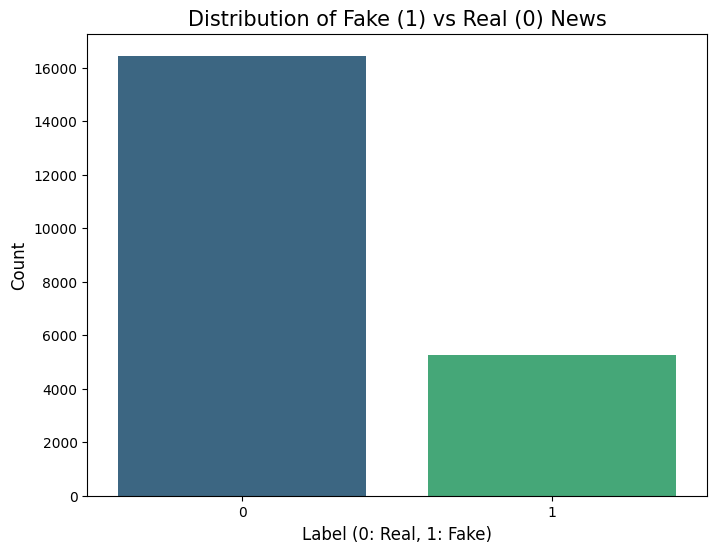

In [9]:
label_counts = df['label'].value_counts()
print(label_counts)

plt.figure(figsize=(8, 6))
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Distribution of Fake (1) vs Real (0) News', fontsize=15)
plt.xlabel('Label (0: Real, 1: Fake)', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.show()

Here as we know, our dataset has real news that almost 4 times larger of fake news.

To see and comprehend the statistics of our dataset, we will go through following steps:


In [10]:
docs = df.set_index('id')['clean_title'].to_dict()

print("Cleaned dataset transformed into a dictionary.")

Cleaned dataset transformed into a dictionary.


In [11]:
total_docs = len(docs)  # length of total documents
print(f"Number of documents : {total_docs}")


Number of documents : 21695


In [12]:
duplicate_ids = df['id'].duplicated().sum()
print(f"Number of duplicate id's: {duplicate_ids}")

Number of duplicate id's: 0


In [13]:
total_words = sum(len(str(text).split()) for text in docs.values())
print(f"Total number of words : {total_words}")

Total number of words : 175259


In [14]:
avg_words = total_words / total_docs if total_docs > 0 else 0
print(f"Avg number of words for a document: {avg_words}")

Avg number of words for a document: 8.07831297533994


We have 8.07 words for average in a document.

In [15]:
fake_docs = df[df['label'] == 1]['clean_title']
real_docs = df[df['label'] == 0]['clean_title']

In [16]:
avg_fake = sum(len(str(t).split()) for t in fake_docs) / len(fake_docs)
avg_real = sum(len(str(t).split()) for t in real_docs) / len(real_docs)

print(f"Avg Words (Fake News): {avg_fake:.2f}")
print(f"Avg Words (Real News): {avg_real:.2f}")

Avg Words (Fake News): 8.12
Avg Words (Real News): 8.06


Here, we see that fake news is a little bit greater average word count than real news. Unfortunately, we cant make any use of this information.

In [17]:
import pandas as pd
from collections import Counter
import os


def get_word_counts(text_series, top_n=20):
    all_words = []
    for text in text_series:
        if isinstance(text, str):
            all_words.extend(text.split())

      # counting words
    counter = Counter(all_words)

      # making table of most used words
    table = pd.DataFrame(counter.most_common(top_n), columns=['Word', 'Frequency'])
    return table

print(" Top 20 words in the dataset")
df_all_words = get_word_counts(df['clean_title'])
display(df_all_words)


 Top 20 words in the dataset


,Word,Frequency
0,new,999
1,kardashian,953
2,jennifer,702
3,2018,686
4,kim,665
5,jenner,626
6,baby,618
7,says,611
8,wedding,595
9,awards,580


In [18]:

print(" Top 20 words in the fake news ")
df_fake_words = get_word_counts(df[df['label'] == 1]['clean_title'])
display(df_fake_words)



 Top 20 words in the fake news 


,Word,Frequency
0,jennifer,400
1,kardashian,387
2,brad,352
3,jenner,322
4,justin,313
5,pitt,302
6,kim,257
7,angelina,251
8,report,233
9,selena,222


In [19]:
print(" Top 20 words in real news")
df_real_words = get_word_counts(df[df['label'] == 0]['clean_title'])
display(df_real_words)

 Top 20 words in real news


,Word,Frequency
0,new,782
1,2018,633
2,kardashian,566
3,awards,545
4,season,530
5,says,480
6,star,464
7,first,456
8,wedding,439
9,baby,430


We are gonna do some feature engineering on this dataset.

It is using the url of the news as a source. We are gonna make a use of it by getting the website names of the news from url and creating a new column named: 'source' of New . With this, we will be able to make a comparison on news according to their source links. This is like calling a new is fake by just seeing the tv channel publishes that new ( like in real life ) . I wont know it will be useful until the end of project, but we'll try.

In [21]:
from urllib.parse import urlparse
df['char_count'] = df['clean_title'].astype(str).apply(len)  # creating character count column of every clean title

df['word_count'] = df['clean_title'].astype(str).apply(lambda x: len(x.split()))  # creating word count column of every title

def extract_domain(url):  # getting source from url ( domain extraction )
    try:

        if pd.isna(url):  # if url is not as it supposed to be
            return "unknown source"    # return unknown source

        domain = urlparse(url).netloc  # get the domain part of the url

        return domain.replace('www.', '')  # delete the www part of url
    except:
        return "unknown source"

df['source'] = df['news_url'].apply(extract_domain)

print("Accomplished. The new columns are added correctly!")
display(df[['title', 'char_count', 'word_count', 'source', 'label']].head())

Accomplished. The new columns are added correctly!


,title,char_count,word_count,source,label
0,Brad Pitt is ‘quietly dating’ as he has ‘secre...,60,8,,1
1,Khloe Kardashian and Tristan Thompson Relation...,55,6,seventeen.com,0
2,Angelina Jolie 'is not happy' with current cus...,58,9,,1
3,BREAKING: Supreme Court Sides With Trump–This ...,58,7,nowtrump.com,1
4,How Hailey Baldwin Makes a Basic White Tank Lo...,47,8,whowhatwear.com,0


In [22]:
df

,id,news_url,title,tweet_ids,label,clean_title,char_count,word_count,source of new,source
0,gossipcop-8787806261,metro.co.uk/2018/03/26/brad-pitt-quietly-datin...,Brad Pitt is ‘quietly dating’ as he has ‘secre...,978426373600509952\t979354358998450177,1,brad pitt ‘quietly dating’ ‘secret meeting’ je...,60,8,,
1,gossipcop-883103,https://www.seventeen.com/celebrity/celebrity-...,Khloe Kardashian and Tristan Thompson Relation...,912862138867355648\t912863141561692160\t912863...,0,khloe kardashian tristan thompson relationship...,55,6,seventeen.com,seventeen.com
2,gossipcop-8887454037,www.msn.com/en-gb/entertainment/movies/celebri...,Angelina Jolie 'is not happy' with current cus...,999666283519070208\t999701373007446016\t999715...,1,angelina jolie happy current custody deal brad...,58,9,,
3,politifact15141,https://nowtrump.com/2018/03/breaking-supreme-...,BREAKING: Supreme Court Sides With Trump–This ...,850509761674174464\t850510063546576896\t850510...,1,breaking supreme court sides trump–this change...,58,7,nowtrump.com,nowtrump.com
4,gossipcop-870570,https://www.whowhatwear.com/hailey-baldwin-whi...,How Hailey Baldwin Makes a Basic White Tank Lo...,892437458352295938\t892437467781095424\t892438...,0,hailey baldwin makes basic white tank look cool,47,8,whowhatwear.com,whowhatwear.com
...,...,...,...,...,...,...,...,...,...,...
21690,gossipcop-4848478073,hollywoodlife.com/2018/06/12/selena-gomez-sing...,Will Selena Gomez Sing About Justin Bieber Or ...,1006748292900933638\t1006748429974982656\t1006...,1,selena gomez sing justin bieber weeknd upcomin...,65,9,,
21691,politifact15534,http://www.thelifebuzz.com/nasa-announced-that...,NASA ANNOUNCED THAT IT COMMUNICATED WITH FOUR ...,881938446583046144\t881938531807109121\t881940...,1,nasa announced communicated four races aliens,45,6,thelifebuzz.com,thelifebuzz.com
21692,gossipcop-878319,http://www.bravotv.com/the-daily-dish/luann-de...,Luann de Lesseps Reveals the Exact Moment That...,905652608987127808\t905653871879405568\t905655...,0,luann lesseps reveals exact moment “final stra...,61,9,bravotv.com,bravotv.com
21693,gossipcop-863389,https://deadline.com/2017/11/fuller-house-netf...,‘Fuller House’ Announces Premiere Date For Sec...,879428570573090816\t879429245755432960\t879429...,0,‘fuller house’ announces premiere date second ...,57,8,deadline.com,deadline.com


Now we can plot the graph of source column


/tmp/ipython-input-2482602165.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fake_sources.values, y=fake_sources.index, palette='Reds_r')


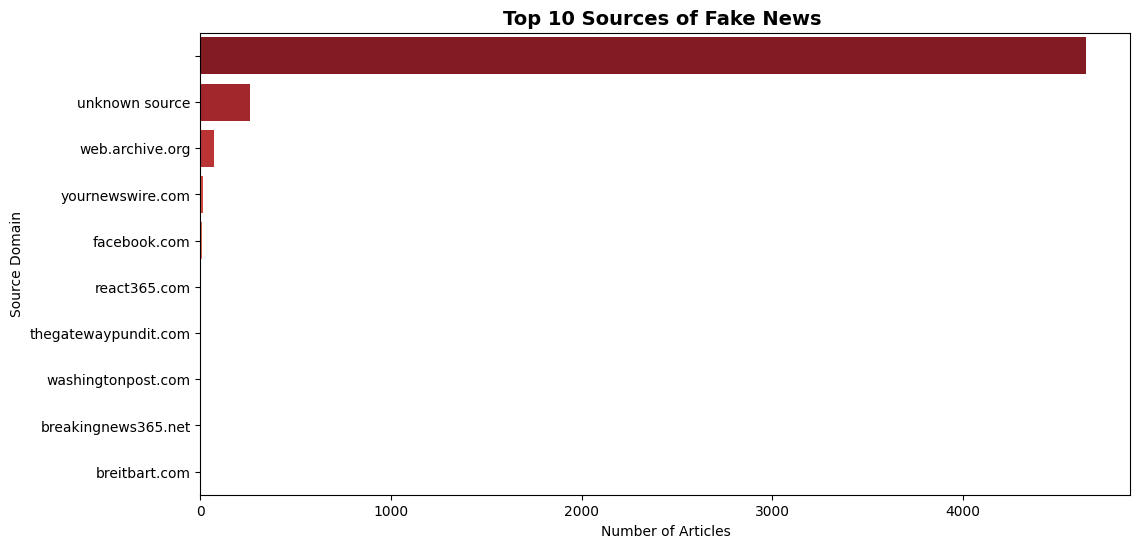

In [23]:
plt.figure(figsize=(12, 6))
fake_sources = df[df['label'] == 1]['source'].value_counts().head(10)

sns.barplot(x=fake_sources.values, y=fake_sources.index, palette='Reds_r')
plt.title('Top 10 Sources of Fake News ', fontsize=14, fontweight='bold')
plt.xlabel('Number of Articles')
plt.ylabel('Source Domain')
plt.show()

Turns out most of the fake news does not have any source, they have empty strings. Unknown sources have some fake news, the web.archive.org , then yournewswire.com, goes on and on.

Its better to call empty strings as also unknown source

In [24]:
df.loc[df['source'] == "", 'source'] = "unknown source"
fake_sources = df[df['label'] == 1]['source'].value_counts().head(10)

In [25]:
print("Top 10 Sources: ")
print(fake_sources)

Top 10 Sources: 
source
unknown source          4905
web.archive.org           69
yournewswire.com          14
facebook.com               6
react365.com               4
thegatewaypundit.com       4
washingtonpost.com         4
breakingnews365.net        3
breitbart.com              3
dailyfeed.news             3
Name: count, dtype: int64


Here we have all numbers of fake sources.

Now we try to see the length of fake and real news to understand if there are some connection between them, using word and character counts.

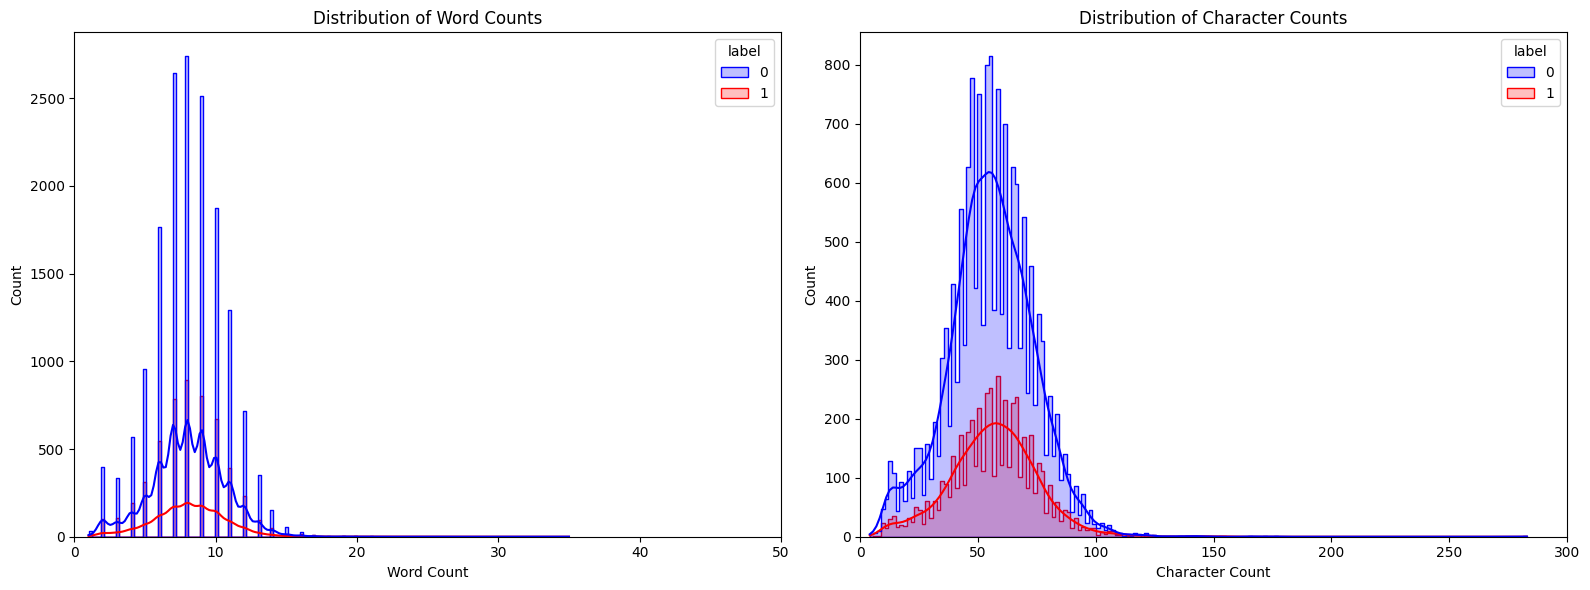

In [26]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# according to distribution of words across the news
sns.histplot(data=df, x='word_count', hue='label', kde=True, element="step", ax=axes[0], palette={0: 'blue', 1: 'red'})
axes[0].set_title('Distribution of Word Counts')
axes[0].set_xlabel('Word Count')
axes[0].set_xlim(0, 50)

# according to distribution of character counts
sns.histplot(data=df, x='char_count', hue='label', kde=True, element="step", ax=axes[1], palette={0: 'blue', 1: 'red'})
axes[1].set_title('Distribution of Character Counts')
axes[1].set_xlabel('Character Count')
axes[1].set_xlim(0, 300)

plt.tight_layout()
plt.show()



In [27]:
 # statistical analysis
print("Average counts for Fake and Real news")
print(df.groupby('label')[['char_count', 'word_count']].mean())

Average counts for Fake and Real news
       char_count  word_count
label                        
0       55.492339    8.063838
1       56.553650    8.123690


We see that fake and real news does not differ much so we can make some assumptions.

We can prove that there is not difference in terms of word and character counts using T-Test.

We saw the source is not that important. But we can use the urls of the news to execute web scraping. It will allow us to gather news from those urls.

In [28]:
!pip install lxml_html_clean  # installing lxml_html_clean to get the news correctly

In [2]:
import pandas as pd
import numpy as np
from newspaper import Article
from tqdm import tqdm
import nltk
import time


nltk.download('punkt')
df = pd.read_csv("cleaned_news.csv")
df_work = df[df['news_url'].str.len() > 10].copy().reset_index(drop=True)  # we select all urls in the dataset that have acceptable lengths

print(f"Scraping for the whole dataset.")
print(f"Total number of links: {len(df_work)}")


def get_full_text_safe(url): # scraping function

    try:
        article = Article(url, language='en', request_timeout=10) # timeout if the url does not respond
        article.download()
        article.parse()

        text = article.text
        if len(text) < 150:
            return np.nan
        if "Access Denied" in text or "403 Forbidden" in text or "Page Not Found" in text:
            return np.nan

        return text
    except:
        return np.nan


tqdm.pandas()  # to check progress
print("\nScraping in process...")
df_work['full_text'] = df_work['news_url'].progress_apply(get_full_text_safe)
df_final_full = df_work.dropna(subset=['full_text'])  # only get the news that are successfully scraped

print(f"Scraping Accomplished !")
print(f"Total News: {len(df_work)}")
print(f"Number of successfull scrapings: {len(df_final_full)}")
print(f"Success Rate: %{(len(df_final_full)/len(df_work))*100:.2f}")

df_final_full.to_csv("scraped_news.csv", index=False) #
print("'scraped_news.csv' is saved.")
display(df_final_full[['title', 'full_text', 'label']].head()) # displaying head of new dataset

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Scraping for the whole dataset.
Total number of links: 21369

Scraping in process...


 23%|██▎       | 4850/21369 [57:30<1:56:56,  2.35it/s]WARNING:newspaper.parsers:fromstring() returned an invalid string: 

...
 95%|█████████▍| 20277/21369 [4:45:33<08:46,  2.08it/s]WARNING:newspaper.parsers:fromstring() returned an invalid string: 

...
100%|██████████| 21369/21369 [5:00:22<00:00,  1.19it/s]


Scraping Accomplished !
Total News: 21369
Number of successfull scrapings: 11113
Success Rate: %52.01
'scraped_news.csv' is saved.


,title,full_text,label
1,Khloe Kardashian and Tristan Thompson Relation...,Seventeen picks products that we think you'll ...,0
5,Lindsey Morgan,American actress (born 1990)\n\nLindsey Marie ...,0
9,Why Did NeNe Leakes Return To 'The Real Housew...,Let's face it. The franchise just hasn't been ...,0
10,Stevie Wonder Quietly Marries Longtime Girlfri...,When Sophie Turner and Joe Jonas met through m...,0
15,19 times Chrissy Teigen got hilariously angry ...,Sam Haysom is the Deputy UK Editor for Mashabl...,0


Here, in all the news, we got %52.06 success rate. Which shows that we got the content of half of all news.

Now we have 11125 (at first try) news that are scraped. For the expand and guarentee the work for later, we will get other news from other sources manually.

In [1]:
import pandas as pd
import numpy as np
from newspaper import Article, Config
from tqdm import tqdm
import nltk
import os

nltk.download('punkt')

BATCH_SIZE = 10  # saving every 10 batch to the csv file in case of errors
OUTPUT_FILE = "scraped_news.csv"

if 'df' not in locals():
    df = pd.read_csv("cleaned_news.csv")

df_work = df[df['news_url'].str.len() > 10].copy().reset_index(drop=True) # we select all urls in the dataset that have acceptable lengths

print(f"Scraping for the whole dataset...")  # messages for output
print(f"Total number of links: {len(df_work)}")
print(f"Each {BATCH_SIZE} news are saved to csv file.")

def get_full_text_safe(url):  # scraping function
    config = Config()
    config.request_timeout = 10  # 10 secs timeout if the url does not respond
    config.browser_user_agent = 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_11_5) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/50.0.2661.102 Safari/537.36'

    try:
        article = Article(url, config=config, language='en')
        article.download()  # download article
        article.parse()

        text = article.text
        if len(text) < 150:
            return np.nan
        if any(x in text for x in ["Access Denied", "403 Forbidden", "Page Not Found", "JavaScript is disabled"]):
            return np.nan

        return text
    except:
        return np.nan

header_written = os.path.exists(OUTPUT_FILE)   # write header if file exists

total_batches = int(np.ceil(len(df_work) / BATCH_SIZE))  # dividing data to batches

for i in tqdm(range(total_batches), desc="Batch Progress:"):  # batching loop
    start_idx = i * BATCH_SIZE
    end_idx = start_idx + BATCH_SIZE

    batch_df = df_work.iloc[start_idx:end_idx].copy()   # get current batch
    batch_df['full_text'] = batch_df['news_url'].apply(get_full_text_safe)   # scraping the batch

    batch_clean = batch_df.dropna(subset=['full_text'])  # only get the news that are successfully scraped

    if not batch_clean.empty:
        batch_clean.to_csv(OUTPUT_FILE, mode='a', index=False, header=not header_written)  # adding to end of file
        header_written = True

print(f"Scraping Accomplished !")
print(f"All of the data saved to : '{OUTPUT_FILE}' .")

  # printing results
try:
    final_df = pd.read_csv(OUTPUT_FILE)
    print(f"Number of successfull scrapings: {len(final_df)}")   # total numbers
    print(f"Success Rate: %{(len(fina_df)/len(df_work))*100:.2f}") # success rate of scrapings, scraped / data size

    print("'scraped_news.csv' is saved.")
    display(final_df[['title', 'full_text', 'label']].head()) # displaying head of new dataset
except:
    print("Scraped news are not saved or file not found.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Scraping for the whole dataset...
Total number of links: 21369
Each 10 news are saved to csv file.


Batch Progress::  23%|██▎       | 484/2137 [58:11<2:40:41,  5.83s/it]WARNING:newspaper.parsers:fromstring() returned an invalid string: 

...
Batch Progress::  95%|█████████▍| 2027/2137 [4:34:15<11:31,  6.29s/it]WARNING:newspaper.parsers:fromstring() returned an invalid string: 

...
Batch Progress:: 100%|██████████| 2137/2137 [4:48:45<00:00,  8.11s/it]


Scraping Accomplished !
All of the data saved to : 'scraped_news.csv' .
Number of successfull scrapings: 10769
'scraped_news.csv' is saved.


,title,full_text,label
0,Khloe Kardashian and Tristan Thompson Relation...,Seventeen picks products that we think you'll ...,0
1,Lindsey Morgan,American actress (born 1990)\n\nLindsey Marie ...,0
2,Why Did NeNe Leakes Return To 'The Real Housew...,Let's face it. The franchise just hasn't been ...,0
3,Stevie Wonder Quietly Marries Longtime Girlfri...,When Sophie Turner and Joe Jonas met through m...,0
4,19 times Chrissy Teigen got hilariously angry ...,Sam Haysom is the Deputy UK Editor for Mashabl...,0


Success rate decreased so we will use first one.